## Computer Vision Project - Image Classification 
## Gathering - EDA

### 1. Introduction

This notebook explores the CIFAR-10 dataset through a concise Exploratory Data Analysis (EDA). The goal is to understand the structure of the data, class balance, visual variability, color characteristics, and image quality before building classification models.

Since CIFAR-10 consists of low-resolution RGB images (32×32 pixels), understanding these properties is particularly important for selecting appropriate preprocessing and modeling strategies. The insights gathered in this analysis will help motivate the later use of convolutional neural networks and transfer learning techniques.

### 2. Load Libraries

In [66]:
import pandas as pd
import numpy as np

# pickle and os libraries
import pickle, os

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Tensorflow cifar10 dataset
from tensorflow.keras.datasets import cifar10


In [67]:
# Color palette global variable
PALETTE = ["#6A0DAD", "#9B30FF", "#C77DFF", "#E0AAFF", "#BF5AF2",
 "#040404", "#4A0E8F", "#2D1B69", "#00B4D8", "#84D5E5"]


### 3. Load the Dataset

In [68]:
# Load CIFAR-10 dataset
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [69]:
# Import dataset labels 
meta_path = os.path.expanduser(
    "~/.keras/datasets/cifar-10-batches-py-target/cifar-10-batches-py/batches.meta"
)
with open(meta_path, "rb") as f:
    meta = pickle.load(f, encoding="bytes")

# Labels dictionary
class_names = {i: name.decode() for i, name in enumerate(meta[b"label_names"])}


In [70]:
# Dataset Structure
train_images.shape

(50000, 32, 32, 3)

In [74]:
# Limit training data from 50k to 10k
n= 10000
train_images = train_images[:n]
train_labels = train_labels[:n]


### 4. EDA

In [75]:
# Dataset Structure
print(f"Train images: {train_images.shape}")
print(f"Train labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}")
print(f"Test labels: {test_labels.shape}")

Train images: (10000, 32, 32, 3)
Train labels: (10000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [76]:
# The array is a 2D, so it needs to be flattened in a 1D array
train_flattened_labels = train_labels.flatten()

#### Class Distribution

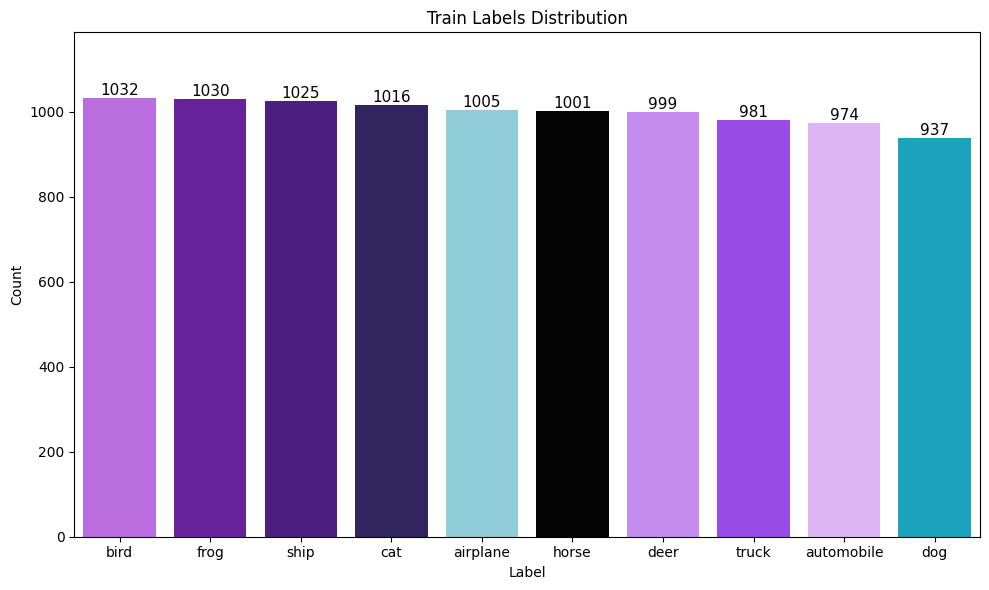

In [ ]:
# Class Distribution Count Plot
plt.figure(figsize = (10,6))

# Label series 
labels_series = pd.Series(train_flattened_labels).map(class_names)

order = labels_series.value_counts().index

ax = sns.countplot(
    x = labels_series, 
    palette = PALETTE, 
    hue = labels_series,
    order = order,
    legend=False
)

# Add labels above each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height)}',
        (p.get_x() + p.get_width()/2, height),
        ha = 'center',
        va = 'bottom',
        fontsize=11
    )
    
# Add padding 
ax.set_ylim(0, max([p.get_height() for p in ax.patches]) * 1.15)

plt.title('Train Labels Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()



In [78]:
# Distribution Table
dist = (
    labels_series
    .value_counts()
    .rename_axis("Label")
    .reset_index(name="Count")
)

# Percentages
dist["Percent"] = (dist["Count"] / dist["Count"].sum() * 100).round(2)

# Order desc
print("Train Label Distribution")
dist = dist.sort_values("Count", ascending=False).reset_index(drop=True)
print(dist.to_string(index=False))


Train Label Distribution
     Label  Count  Percent
      bird   1032    10.32
      frog   1030    10.30
      ship   1025    10.25
       cat   1016    10.16
  airplane   1005    10.05
     horse   1001    10.01
      deer    999     9.99
     truck    981     9.81
automobile    974     9.74
       dog    937     9.37


**Note**: The training set is very well balanced across all classes.
Each category represents roughly 10% of the dataset, with less than 1% variation between the most and least frequent labels.  
This ensures that the model is not biased toward any specific class and can learn all categories in a uniform way.

#### Sample per Class

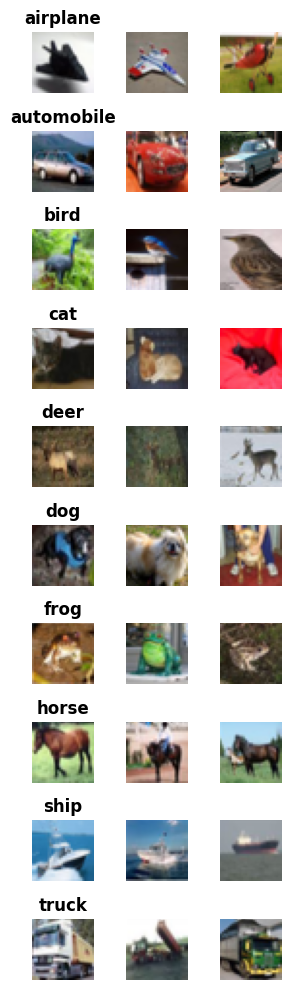

In [79]:
num_samples = 3
unique_classes = np.unique(train_flattened_labels)

plt.figure(figsize=(3, 10))

idx = 1
for cls in unique_classes:
    # current class indices
    cls_indices = np.where(train_flattened_labels == cls)[0]
    
    # Select 3 random images
    selected = cls_indices[:num_samples]
    
    for i, img_idx in enumerate(selected):
        plt.subplot(len(unique_classes), num_samples, idx)
        plt.imshow(train_images[img_idx])
        plt.axis("off")
        
        # Title 
        if i == 0:
            plt.title(class_names[cls], fontsize=12, fontweight="bold")
        
        idx += 1

plt.tight_layout()
plt.show()

**Note**: Visual inspection shows strong variability within the dataset.

Objects appear under different lighting conditions, viewing angles, scales, poses, and backgrounds.  
Several images are also blurry or noisy because of the very low 32×32 resolution.

Some classes, such as airplane and ship, often contain more consistent backgrounds, while others like cat, dog, and deer appear in more complex visual environments.

Overall, the dataset contains significant intra-class variability and limited visual detail, making generalization more challenging for the model.

#### Color Distribution

In [80]:
# Compute the average RGB values for each class
rgb_means = []
for cls in np.unique(train_flattened_labels):
    # Select all images belonging to the current class
    imgs = train_images[train_flattened_labels == cls]
    
    # Compute the mean RGB value across all pixels and all images
    mean_rgb = imgs.mean(axis=(0, 1, 2))
    
    # Store class name and RGB means
    rgb_means.append([class_names[cls], *mean_rgb])

# Create a DataFrame for easier visualization
df_rgb = pd.DataFrame(rgb_means, columns=["Class", "R_mean", "G_mean", "B_mean"])

# Display the table
df_rgb

,Class,R_mean,G_mean,B_mean
0,airplane,135.111784,143.817455,151.174880
1,automobile,121.013774,115.849347,113.788636
2,bird,124.512871,125.942054,108.176559
3,cat,126.692713,116.177242,105.637581
4,deer,120.349861,118.597384,96.638506
5,dog,127.440175,118.046482,106.262818
6,frog,119.513783,111.069292,87.381988
7,horse,128.889310,122.794304,106.555754
8,ship,125.915441,134.191671,141.321525
9,truck,129.076439,125.658823,123.292092


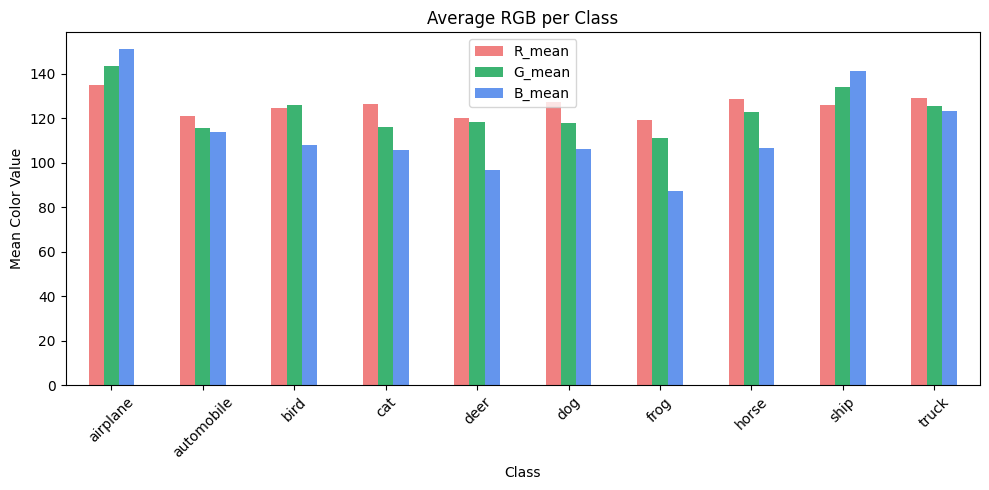

In [81]:
# Plot the RGB means for each class
ax = df_rgb.set_index("Class").plot(
    kind="bar",
    figsize=(10, 5),
    color={
        "R_mean": "lightcoral", # red
        "G_mean": "mediumseagreen", # green
        "B_mean": "cornflowerblue" # blue
    }
)
# Add title and labels
plt.title("Average RGB per Class")
plt.ylabel("Mean Color Value")
plt.xticks(rotation=45)

# Improve layout
plt.tight_layout()
plt.show()

**Note**: The RGB mean values reveal visible color differences across classes.

Airplane and ship images tend to contain stronger blue-channel values because of sky and water backgrounds, while animal classes usually show more balanced RGB distributions with natural brown and green tones.

Frog images show relatively lower blue-channel values compared to red and green, while vehicle classes such as automobile and truck appear more color-neutral overall.

These patterns suggest that some classes have more distinctive color characteristics, while others overlap more strongly and may therefore be harder for the model to separate.

#### Pixel Intensity Histogram

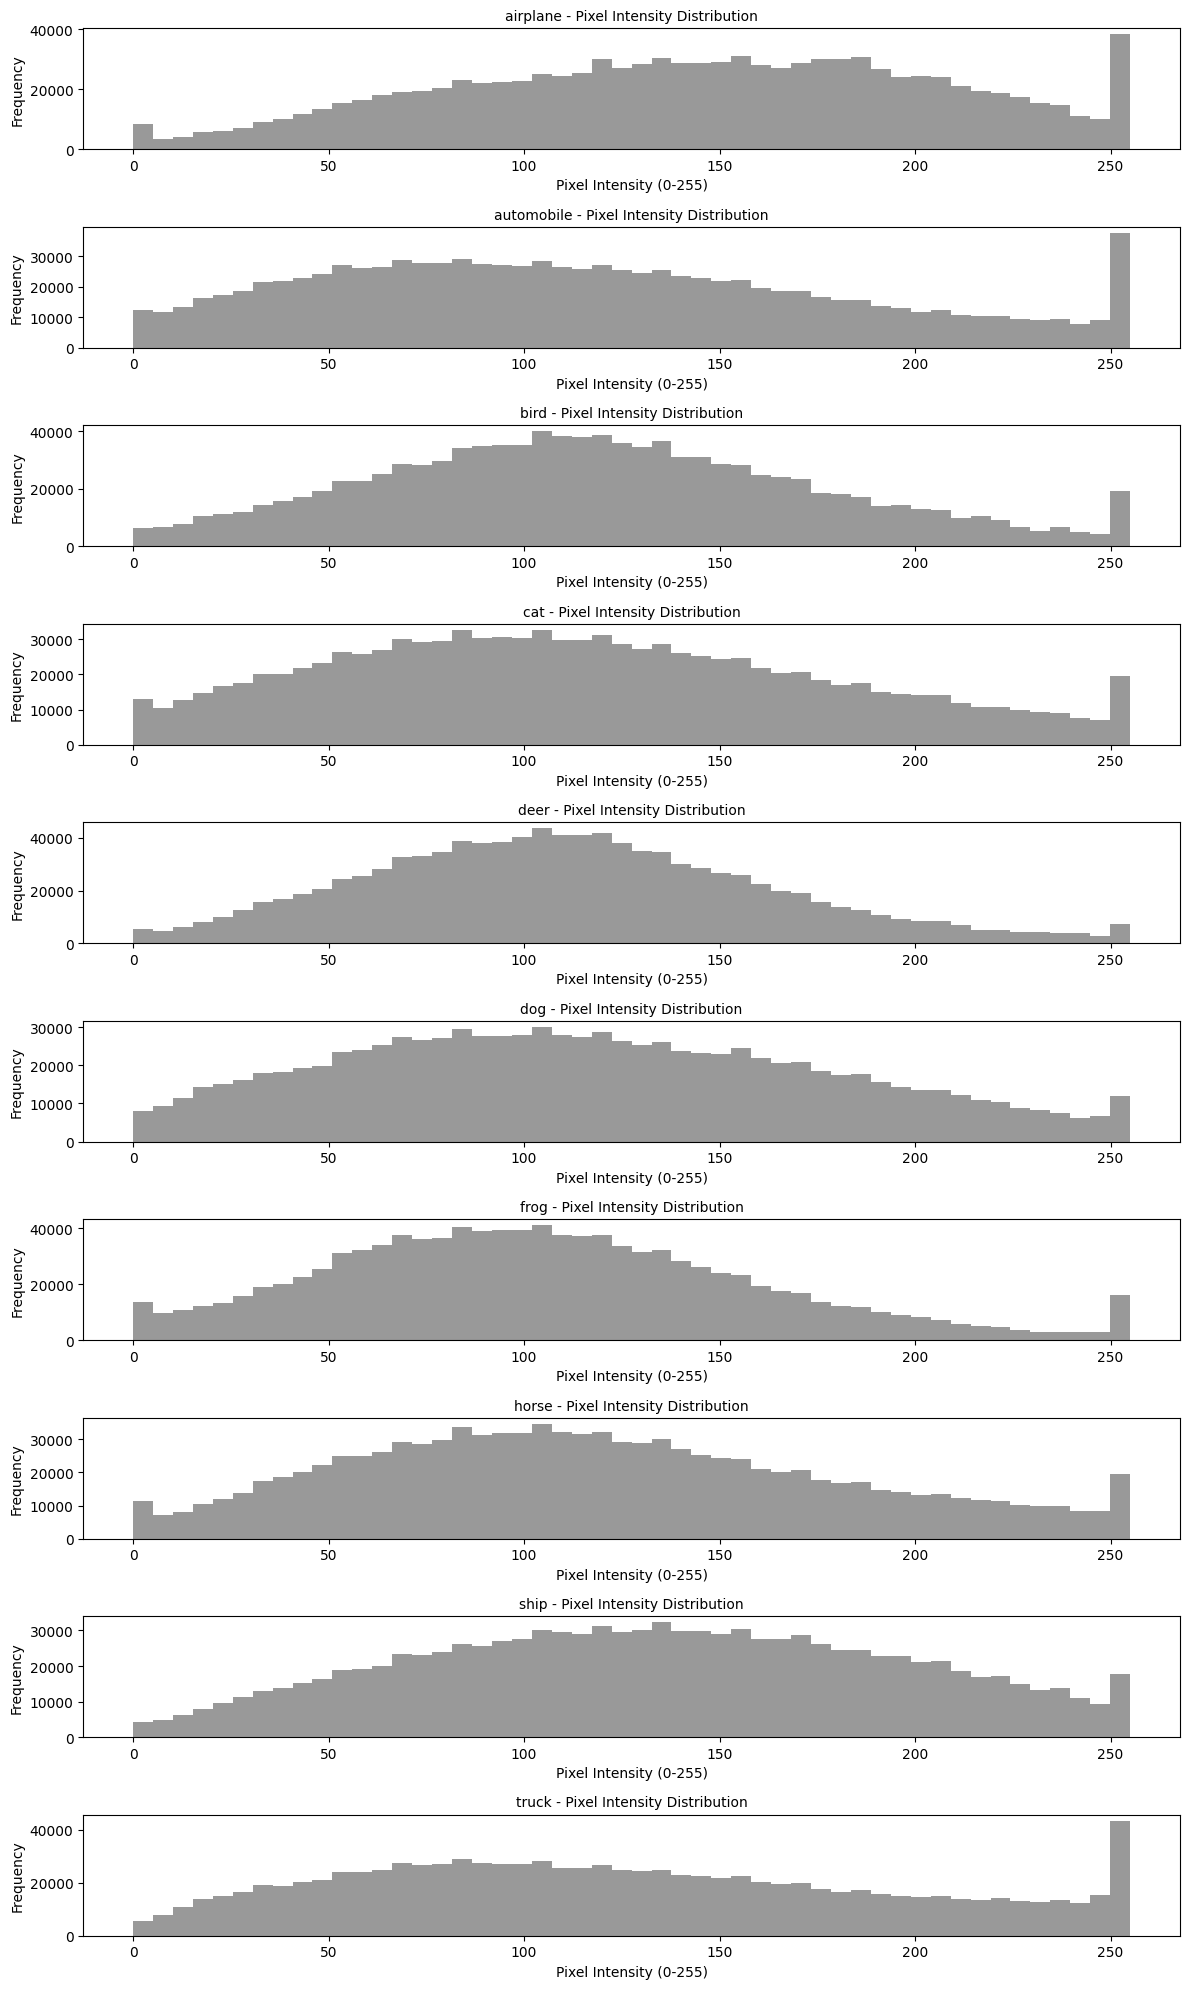

In [64]:
# Flatten labels to ensure correct indexing


# Number of bins for the histogram
bins = 50

plt.figure(figsize=(12, 20))

for i, cls in enumerate(np.unique(train_flattened_labels)):
    # Select all images of the class
    imgs = train_images[train_flattened_labels == cls]
    
    # Convert to grayscale for intensity analysis
    # (simple average of RGB channels)
    gray_imgs = imgs.mean(axis=3)
    
    # Flatten all pixel values into a single vector
    pixel_values = gray_imgs.flatten()
    
    # Plot histogram
    plt.subplot(10, 1, i + 1)
    plt.hist(pixel_values, bins=bins, color="gray", alpha=0.8)
    
    # Title and labels
    plt.title(f"{class_names[cls]} - Pixel Intensity Distribution", fontsize=10)
    plt.xlabel("Pixel Intensity (0-255)")
    plt.ylabel("Frequency")
    
plt.tight_layout()
plt.show()

**Note**: Pixel intensity histograms reveal differences in brightness and contrast across classes.

Classes such as airplane and ship tend to show higher intensity values because of brighter backgrounds, while animal classes often exhibit broader distributions due to more varied textures and lighting conditions.

These differences provide additional insight into the visual complexity of the dataset and may influence how easily certain classes can be distinguished.

### EDA Summary

The exploratory analysis highlighted several characteristics of the CIFAR-10 dataset that make image classification challenging.

The images are extremely small (32×32 pixels), resulting in limited visual detail and occasional blur. Visual inspection also revealed substantial variability within classes, including differences in background, viewpoint, scale, lighting conditions, and object appearance.

The class distribution is well balanced, reducing the risk of bias toward specific categories. Color statistics and pixel intensity distributions showed that some classes possess distinctive visual characteristics, while others share overlapping patterns that may complicate classification.

Overall, the analysis suggests that successful classification will require models capable of learning robust visual features and generalizing across highly variable image conditions. These observations motivate the use of convolutional neural networks and transfer learning techniques during the modeling phase.